In [1]:
#We make sure to import all the necessary libraries for our analysis
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import pearsonr, linregress, spearmanr


In [2]:
#We read the datasets into pandas dataframes
df_customer=pd.read_csv('data/olist_customers_dataset.csv')
df_location=pd.read_csv('data/olist_geolocation_dataset.csv')
df_order_items=pd.read_csv('data/olist_order_items_dataset.csv')
df_order_payments=pd.read_csv('data/olist_order_payments_dataset.csv')
df_order_reviews=pd.read_csv('data/olist_order_reviews_dataset.csv')
df_orders=pd.read_csv('data/olist_orders_dataset.csv')
df_products=pd.read_csv('data/olist_products_dataset.csv')
df_sellers=pd.read_csv('data/olist_sellers_dataset.csv')
df_category_translation=pd.read_csv('data/product_category_name_translation.csv')


In [3]:
"""
Questions to answer:
1. VOLUME AND QUANTITY 
Which are the top 10 cities by number of orders?
Which product category is the best-selling?
How many orders per month? Is there a growth trend?
What is the average number of items per order?
"""

'\nQuestions to answer:\n1. VOLUME AND QUANTITY \nWhich are the top 10 cities by number of orders?\nWhich product category is the best-selling?\nHow many orders per month? Is there a growth trend?\nWhat is the average number of items per order?\n'

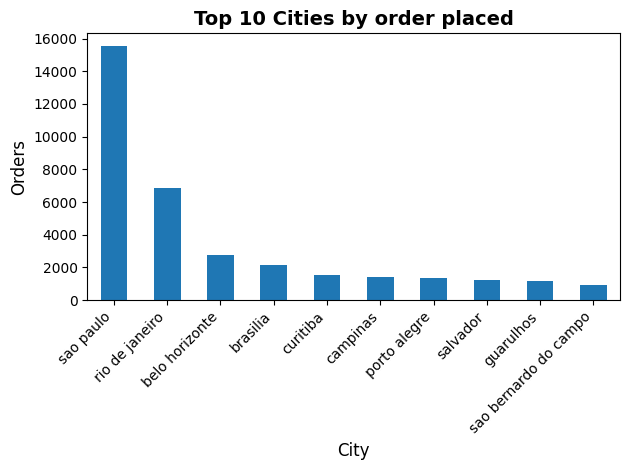

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
Name: count, dtype: int64


In [4]:
#Which are the top 10 cities by number of orders?
#Joining orders and customers information
df_customers_orders=df_orders.merge(df_customer, how='left', on='customer_id')
top_10_cities=df_customers_orders['customer_city'].value_counts().head(10)
top_10_cities.plot(kind='bar')
plt.title('Top 10 Cities by order placed', fontsize=14, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotates city names so they don't overlap
plt.tight_layout()
plt.show()
print(top_10_cities)

                        items_sold  orders  items_per_order
product_category_name                                      
cama_mesa_banho              11115    9417             1.18
beleza_saude                  9670    8836             1.09
esporte_lazer                 8641    7720             1.12
informatica_acessorios        7827    6689             1.17
moveis_decoracao              8334    6449             1.29
utilidades_domesticas         6964    5884             1.18
relogios_presentes            5991    5624             1.07
telefonia                     4545    4199             1.08
automotivo                    4235    3897             1.09
brinquedos                    4117    3886             1.06


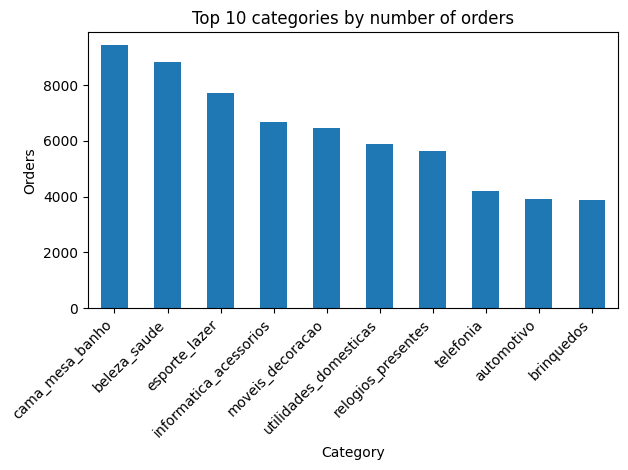

In [101]:
#Which product category is the best-selling?
#Joining Orders DataFrame, OrderItems DataFrame, Products Info DataFrame
df_orders_items_info=df_orders.merge(df_order_items,how='left',on='order_id')\
                        .merge(df_products,how='left', on='product_id' )

#Two ways to measure "best-selling": items sold vs number of orders
best_product=df_orders_items_info.groupby('product_category_name').agg(
    items_sold=('order_id', 'count'),
    orders=('order_id', 'nunique')
).sort_values('orders', ascending=False).head(10)
best_product['items_per_order']=(best_product['items_sold']/best_product['orders']).round(2)
print(best_product)

best_product['orders'].plot(kind='bar')
plt.title('Top 10 categories by number of orders')
plt.xlabel('Category')
plt.ylabel('Orders')
plt.xticks(rotation=45, ha='right')  # Rotates category names so they don't overlap
plt.tight_layout()
plt.show()

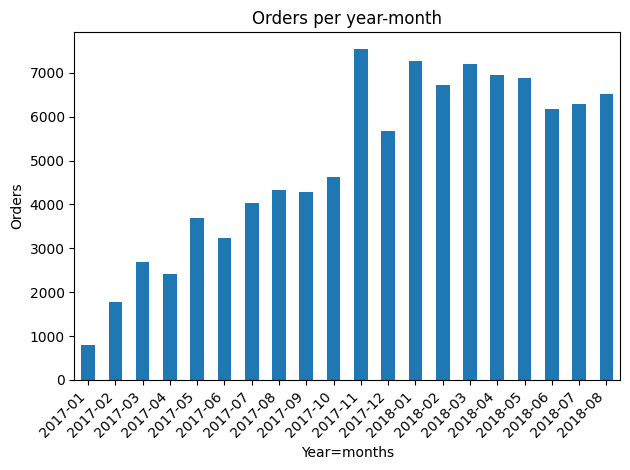

year_month
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
Freq: M, dtype: int64


In [102]:
#How many orders per month? Is there a growth trend?
#Converting string column into date time data type
df_orders['order_purchase_timestamp']=pd.to_datetime(df_orders['order_purchase_timestamp'])
#Add a column that includes only year-month by using to_period('M')
df_orders['year_month']=df_orders['order_purchase_timestamp'].dt.to_period('M')
#Keep only months with complete data (Sep-Dec 2016 and Sep-Oct 2018 have almost no orders)
df_orders_complete=df_orders[(df_orders['year_month']>=pd.Period('2017-01', freq='M')) &
                             (df_orders['year_month']<=pd.Period('2018-08', freq='M'))]
#Group by period and calculate the size
orders_per_month = df_orders_complete.groupby('year_month').size()
orders_per_month.plot(kind='bar')
plt.title('Orders per year-month')
plt.xlabel('Year=months')
plt.ylabel('Orders')
plt.xticks(rotation=45, ha='right')  # Rotates city names so they don't overlap
plt.tight_layout()
plt.show()
print(orders_per_month)


In [103]:
#What is the average number of items per order?
#For this answer re use the same DataFrame created before.
items_per_order=df_order_items.groupby('order_id').size()
avg_items=items_per_order.mean()
print(avg_items)

1.1417306873695092


In [104]:
"""
2. MONEY AND SALES 
What is the average order value?
Which categories generate the most revenue?
What is the correlation between price and quantity sold?
How much does shipping affect the final price?
"""

'\n2. MONEY AND SALES \nWhat is the average order value?\nWhich categories generate the most revenue?\nWhat is the correlation between price and quantity sold?\nHow much does shipping affect the final price?\n'

In [105]:
#What is the average order value?
#Total avg price
avg_price = df_order_items.groupby('order_id', as_index=False).agg(total_order=('price','sum'))['total_order'].mean()
print(avg_price)
#Details of the analisis
order_totals = df_order_items.groupby('order_id')['price'].sum()
print(f'Mean: R${order_totals.mean():.2f}')
print(f'Median: R${order_totals.median():.2f}')
print(f'Range: R${order_totals.min():.2f} - R${order_totals.max():.2f}')



137.7540763788945
Mean: R$137.75
Median: R$86.90
Range: R$0.85 - R$13440.00


     product_category_name  total_revenue  quantity_sold   avg_price  \
11            beleza_saude     1258681.34           9670  130.163531   
66      relogios_presentes     1205005.68           5991  201.135984   
13         cama_mesa_banho     1036988.68          11115   93.296327   
32           esporte_lazer      988048.97           8641  114.344285   
44  informatica_acessorios      911954.32           7827  116.513903   
54        moveis_decoracao      729762.49           8334   87.564494   
26              cool_stuff      635290.85           3796  167.357969   
72   utilidades_domesticas      632248.66           6964   90.788148   
8               automotivo      592720.11           4235  139.957523   
40      ferramentas_jardim      485256.46           4347  111.630196   

    num_products  
11          2444  
66          1329  
13          3029  
32          2867  
44          1639  
54          2657  
26           789  
72          2335  
8           1900  
40           753 

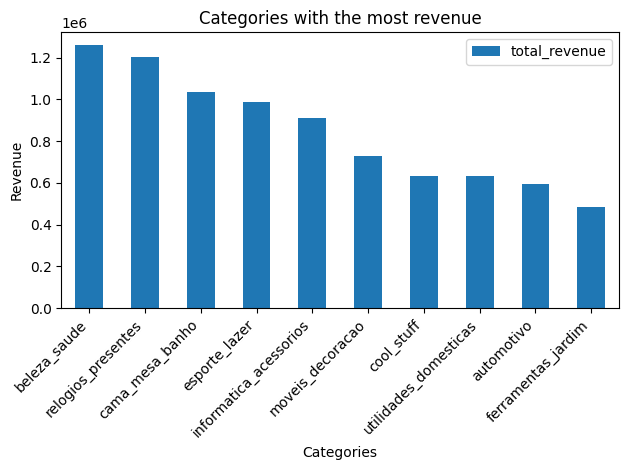

In [106]:
#Which categories generate the most revenue?
revenue_by_category = df_order_items.merge(df_products, on='product_id') \
    .groupby('product_category_name', as_index=False).agg(
        total_revenue=('price', 'sum'),
        quantity_sold=('order_item_id', 'count'),
        avg_price=('price', 'mean'),
        num_products=('product_id', 'nunique')
    ).sort_values('total_revenue', ascending=False).head(10)
print(revenue_by_category)
revenue_by_category.plot(kind='bar',x='product_category_name',y='total_revenue')
plt.title('Categories with the most revenue')
plt.xlabel('Categories')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')  # Rotates city names so they don't overlap
plt.tight_layout()
plt.show()



In [107]:
#What is the correlation between price and quantity sold?
#Calculate how many items were sold by product
quantity_by_product=df_order_items.groupby('product_id').size().reset_index(name='quantity_sold')
print(quantity_by_product.head())

#Obtain average price per product (one row per product)
price_by_product=df_order_items.groupby('product_id')['price'].mean().reset_index()
print(price_by_product.head())

product_analysis=quantity_by_product.merge(price_by_product, on='product_id')

#Sanity check: each product must appear only once
print(product_analysis['product_id'].is_unique)

#Pearson: linear relationship (sensitive to outliers)
correlation, p_value=pearsonr(product_analysis['price'], product_analysis['quantity_sold'])
print(f"Pearson: {correlation:.3f} (p-value: {p_value:.4f})")

#Spearman: rank-based relationship (robust to outliers)
correlation_spearman, p_value_spearman=spearmanr(product_analysis['price'], product_analysis['quantity_sold'])
print(f"Spearman: {correlation_spearman:.3f} (p-value: {p_value_spearman:.4f})")


                         product_id  quantity_sold
0  00066f42aeeb9f3007548bb9d3f33c38              1
1  00088930e925c41fd95ebfe695fd2655              1
2  0009406fd7479715e4bef61dd91f2462              1
3  000b8f95fcb9e0096488278317764d19              2
4  000d9be29b5207b54e86aa1b1ac54872              1
                         product_id   price
0  00066f42aeeb9f3007548bb9d3f33c38  101.65
1  00088930e925c41fd95ebfe695fd2655  129.90
2  0009406fd7479715e4bef61dd91f2462  229.00
3  000b8f95fcb9e0096488278317764d19   58.90
4  000d9be29b5207b54e86aa1b1ac54872  199.00
True
Pearson: -0.032 (p-value: 0.0000)
Spearman: -0.071 (p-value: 0.0000)


Overall freight share (weighted): 14.21%
                           order_id   price  freight_value  freight_percent
0  00010242fe8c5a6d1ba2dd792cb16214   58.90          13.29        18.409752
1  00018f77f2f0320c557190d7a144bdd3  239.90          19.93         7.670400
2  000229ec398224ef6ca0657da4fc703e  199.00          17.87         8.239959
3  00024acbcdf0a6daa1e931b038114c75   12.99          12.79        49.612102
4  00042b26cf59d7ce69dfabb4e55b4fd9  199.90          18.14         8.319574
Mean: 20.88%
Median: 18.33%
Std: 12.57%
price_range
Low            33.66
Medium-low     20.45
Medium-high    14.30
High            8.85
Name: freight_percent, dtype: float64


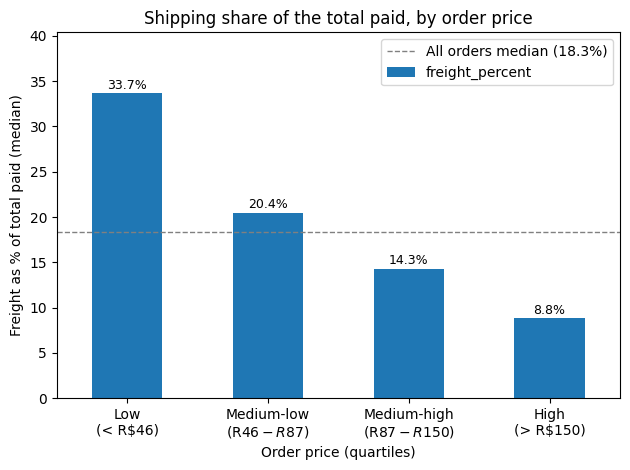

In [108]:
#How much does shipping affect the final price?
#Freight share = freight / (price + freight): out of what the customer pays, how much is shipping

#1) Overall (weighted): business view, all freight divided by all money paid
total_orders=df_order_items['price'].sum()
total_freight_value=df_order_items['freight_value'].sum()
freight_percent=total_freight_value/(total_orders+total_freight_value)*100
print(f"Overall freight share (weighted): {freight_percent:.2f}%")

#2) Per order: customer view, each order counts the same
price_per_order=df_order_items.groupby('order_id')['price'].sum().reset_index()
freight_per_order=df_order_items.groupby('order_id')['freight_value'].sum().reset_index()
total_per_orders=price_per_order.merge(freight_per_order,on='order_id')
total_per_orders['freight_percent']=(total_per_orders['freight_value']/
                                     (total_per_orders['price']+total_per_orders['freight_value']))*100
print(total_per_orders.head())
print(f"Mean: {total_per_orders['freight_percent'].mean():.2f}%")
print(f"Median: {total_per_orders['freight_percent'].median():.2f}%")
print(f"Std: {total_per_orders['freight_percent'].std():.2f}%")

#3) Freight share by order price quartile: does shipping weigh more on cheap orders?
total_per_orders['price_range']=pd.qcut(total_per_orders['price'], q=4,
                                        labels=['Low', 'Medium-low', 'Medium-high', 'High'])
freight_by_price_range=total_per_orders.groupby('price_range', observed=True)['freight_percent'].median().round(2)
print(freight_by_price_range)
#Plot: median freight share by order price quartile
#Price limits of each quartile, to show them in the labels
q1, q2, q3=total_per_orders['price'].quantile([0.25, 0.5, 0.75])
x_labels=[f'Low\n(< R${q1:.0f})',
          f'Medium-low\n(R${q1:.0f} - R${q2:.0f})',
          f'Medium-high\n(R${q2:.0f} - R${q3:.0f})',
          f'High\n(> R${q3:.0f})']

median_freight_percent=total_per_orders['freight_percent'].median()

ax=freight_by_price_range.plot(kind='bar')
plt.title('Shipping share of the total paid, by order price')
plt.xlabel('Order price (quartiles)')
plt.ylabel('Freight as % of total paid (median)')
plt.ylim(0, freight_by_price_range.max() * 1.2)  # Extra space for the labels
ax.set_xticklabels(x_labels, rotation=0)

#Reference line: median freight share across all orders
ax.axhline(median_freight_percent, color='gray', linestyle='--', linewidth=1,
           label=f'All orders median ({median_freight_percent:.1f}%)')

#Percentage above each bar
for i, value in enumerate(freight_by_price_range):
    ax.text(i, value + 0.5, f'{value:.1f}%', ha='center', fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()

In [109]:

"""3. CUSTOMER SATISFACTION ⭐
What is the average review rating? Is it improving?
Which categories have the best/worst ratings?
Is there a relationship between product price and rating?
Is there a relationship between delivery time and satisfaction?"""

'3. CUSTOMER SATISFACTION ⭐\nWhat is the average review rating? Is it improving?\nWhich categories have the best/worst ratings?\nIs there a relationship between product price and rating?\nIs there a relationship between delivery time and satisfaction?'

In [110]:
#What is the average review rating? Is it improving?
avg_rating=df_order_reviews['review_score'].mean().round(2)
print(avg_rating)
df_order_reviews['review_answer_timestamp']=pd.to_datetime(df_order_reviews['review_answer_timestamp'])
df_order_reviews['month_year']=df_order_reviews['review_answer_timestamp'].dt.to_period('M')
avg_rating_by_time=df_order_reviews.groupby('month_year')['review_score'].mean().reset_index()
print(avg_rating_by_time)

4.09
   month_year  review_score
0     2016-10      4.158940
1     2016-11      3.218182
2     2016-12      2.360000
3     2017-01      4.398990
4     2017-02      4.290936
5     2017-03      4.028743
6     2017-04      4.049929
7     2017-05      4.085424
8     2017-06      4.121590
9     2017-07      4.177275
10    2017-08      4.224007
11    2017-09      4.195181
12    2017-10      4.183840
13    2017-11      4.110751
14    2017-12      3.947011
15    2018-01      4.042245
16    2018-02      4.013451
17    2018-03      3.768025
18    2018-04      3.883581
19    2018-05      4.196196
20    2018-06      4.175935
21    2018-07      4.287429
22    2018-08      4.209052
23    2018-09      4.308544
24    2018-10      3.944444


Rows before: 113,131 | after removing duplicates: 100,032
Best rated categories:
     product_category_name      mean  count
48  livros_interesse_geral  4.462598    508
49         livros_tecnicos  4.405405    259
2        alimentos_bebidas  4.385965    228
50        malas_acessorios  4.331068   1030
1                alimentos  4.276404    445

Worst rated categories:
               product_category_name      mean  count
14                     casa_conforto  3.859296    398
25  construcao_ferramentas_seguranca  3.849398    166
7                              audio  3.827586    348
38           fashion_roupa_masculina  3.702703    111
55                 moveis_escritorio  3.617508   1268


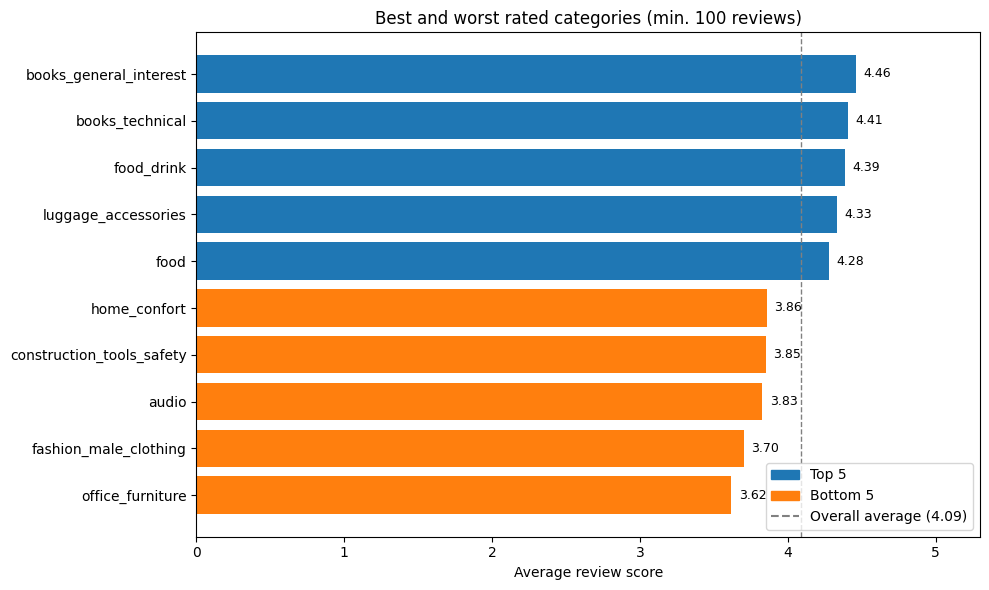

In [111]:
#Which categories have the best/worst ratings?
df_reviews_and_categories=df_order_reviews.merge(df_order_items,on='order_id',how='left')\
                            .merge(df_products,on='product_id',how='left')

#An order with several items repeats its review once per item
#Keep one review per category per order
df_reviews_unique=df_reviews_and_categories.drop_duplicates(subset=['review_id','order_id','product_category_name'])
print(f"Rows before: {len(df_reviews_and_categories):,} | after removing duplicates: {len(df_reviews_unique):,}")

#Average rating and number of reviews per category
df_categories_reviews=df_reviews_unique.groupby('product_category_name')['review_score'].agg(['mean','count']).reset_index()

#Keep only categories with enough reviews to be reliable
df_categories_reviews=df_categories_reviews[df_categories_reviews['count']>=100].sort_values(by='mean',ascending=False)

print("Best rated categories:")
print(df_categories_reviews.head(5))
print("\nWorst rated categories:")
print(df_categories_reviews.tail(5))

#Plot: 5 best and 5 worst rated categories (minimum 100 reviews)
from matplotlib.patches import Patch

best_worst=pd.concat([df_categories_reviews.head(5), df_categories_reviews.tail(5)])
#Translate category names to English
best_worst=best_worst.merge(df_category_translation, on='product_category_name', how='left')
#Ascending order so the best category ends up at the top of a horizontal bar chart
best_worst=best_worst.sort_values('mean')

#Blue for the best 5, orange for the worst 5
best_names=df_categories_reviews.head(5)['product_category_name'].tolist()
colors=['tab:blue' if name in best_names else 'tab:orange' for name in best_worst['product_category_name']]

fig, ax=plt.subplots(figsize=(10, 6))
ax.barh(best_worst['product_category_name_english'], best_worst['mean'], color=colors)

#Overall average as reference line
ax.axvline(avg_rating, color='gray', linestyle='--', linewidth=1)

#Value at the end of each bar
for i, mean in enumerate(best_worst['mean']):
    ax.text(mean + 0.05, i, f'{mean:.2f}', va='center', fontsize=9)

plt.title('Best and worst rated categories (min. 100 reviews)')
plt.xlabel('Average review score')
plt.xlim(0, 5.3)  # Extra space so the labels fit
ax.legend(handles=[Patch(color='tab:blue', label='Top 5'),
                   Patch(color='tab:orange', label='Bottom 5'),
                   plt.Line2D([0], [0], color='gray', linestyle='--', label=f'Overall average ({avg_rating})')],
          loc='lower right')
plt.tight_layout()
plt.show()

True
Pearson: -0.040 (p-value: 0.0000)
Spearman: -0.032 (p-value: 0.0000)
             mean  count
price_range             
Low          4.17  24593
Medium-low   4.13  24467
Medium-high  4.11  24516
High         4.00  24341
0.25     45.9
0.50     86.9
0.75    149.9
Name: price, dtype: float64


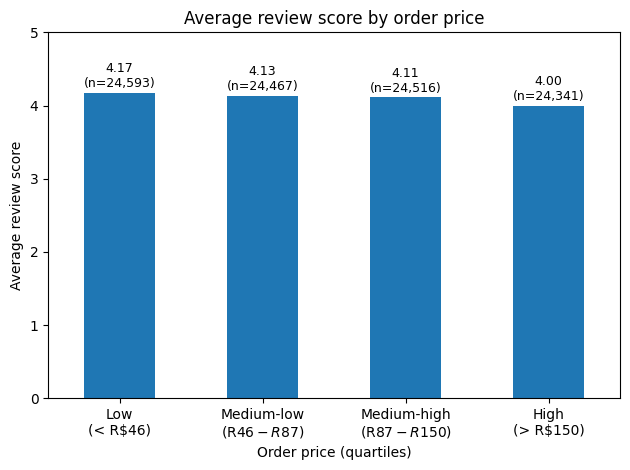

In [112]:
#Is there a relationship between product price and rating?
#Unit of analysis: the order (one review per order, but an order can have several items)
#Total price per order (same calculation as in the shipping cell)
price_per_order=df_order_items.groupby('order_id')['price'].sum().reset_index()
#Review per order (a few orders have more than one review, so we average them)
review_per_order=df_order_reviews.groupby('order_id')['review_score'].mean().reset_index()

df_price_review=price_per_order.merge(review_per_order, on='order_id')

#Sanity check: each order must appear only once
print(df_price_review['order_id'].is_unique)

#Pearson: linear relationship (sensitive to extreme prices)
correlation_price_review, p_value=pearsonr(df_price_review['price'], df_price_review['review_score'])
print(f"Pearson: {correlation_price_review:.3f} (p-value: {p_value:.4f})")

#Spearman: rank-based relationship (robust to extreme prices)
correlation_spearman, p_value_spearman=spearmanr(df_price_review['price'], df_price_review['review_score'])
print(f"Spearman: {correlation_spearman:.3f} (p-value: {p_value_spearman:.4f})")

#Average rating by price quartile (each group has 25% of the orders)
df_price_review['price_range']=pd.qcut(df_price_review['price'], q=4,
                                       labels=['Low', 'Medium-low', 'Medium-high', 'High'])
rating_by_price_range=df_price_review.groupby('price_range', observed=True)['review_score'].agg(['mean','count']).round(2)
print(rating_by_price_range)

#Price limits of each quartile
print(df_price_review['price'].quantile([0.25, 0.5, 0.75]))
#Plot: average rating by price quartile
#Price limits of each quartile, to show them in the labels
q1, q2, q3=df_price_review['price'].quantile([0.25, 0.5, 0.75])
x_labels=[f'Low\n(< R${q1:.0f})',
          f'Medium-low\n(R${q1:.0f} - R${q2:.0f})',
          f'Medium-high\n(R${q2:.0f} - R${q3:.0f})',
          f'High\n(> R${q3:.0f})']

ax=rating_by_price_range['mean'].plot(kind='bar')
plt.title('Average review score by order price')
plt.xlabel('Order price (quartiles)')
plt.ylabel('Average review score')
plt.ylim(0, 5)  # Full 0-5 scale so small differences are not exaggerated
ax.set_xticklabels(x_labels, rotation=0)

#Value and number of reviews above each bar
for i, (mean, count) in enumerate(zip(rating_by_price_range['mean'], rating_by_price_range['count'])):
    ax.text(i, mean + 0.08, f'{mean:.2f}\n(n={count:,})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Pearson: -0.334 (p-value: 0.0000)
Spearman: -0.234 (p-value: 0.0000)
                mean  count
delivery_range             
0-7 days        4.41  33685
8-14 days       4.29  36396
15-21 days      4.10  15381
22-30 days      3.49   6865
30+ days        2.18   4032


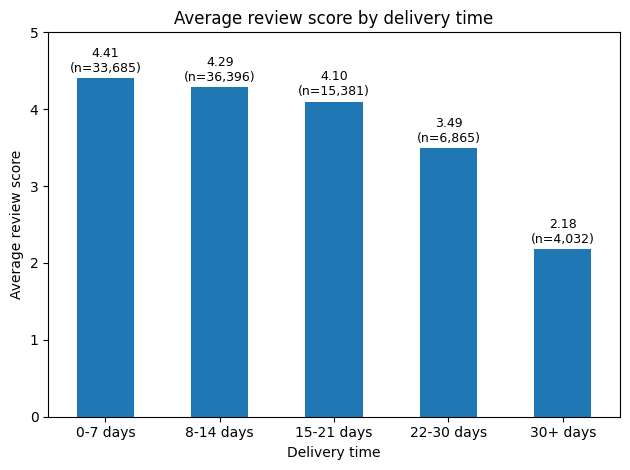

In [113]:
#Is there a relationship between delivery time and satisfaction?
#Delivery time = purchase date until the customer receives the order
df_reviews_and_time=df_order_reviews.merge(df_orders,on='order_id',how='left')\
                            .dropna(subset=['order_delivered_customer_date', 'review_score'])
df_reviews_and_time['order_purchase_timestamp']=pd.to_datetime(df_reviews_and_time['order_purchase_timestamp'])
df_reviews_and_time['order_delivered_customer_date']=pd.to_datetime(df_reviews_and_time['order_delivered_customer_date'])

df_reviews_and_time['delivery_time_days']=(df_reviews_and_time['order_delivered_customer_date']-df_reviews_and_time['order_purchase_timestamp']).dt.days

#Pearson: linear relationship
correlation, p_value = pearsonr(df_reviews_and_time['delivery_time_days'], df_reviews_and_time['review_score'])
print(f"Pearson: {correlation:.3f} (p-value: {p_value:.4f})")

#Spearman: rank-based relationship (better for 1-5 scores and skewed days)
correlation_spearman, p_value_spearman = spearmanr(df_reviews_and_time['delivery_time_days'], df_reviews_and_time['review_score'])
print(f"Spearman: {correlation_spearman:.3f} (p-value: {p_value_spearman:.4f})")

#Average rating by delivery time range (easier to interpret)
df_reviews_and_time['delivery_range']=pd.cut(df_reviews_and_time['delivery_time_days'],
                                              bins=[-1, 7, 14, 21, 30, 1000],
                                              labels=['0-7 days', '8-14 days', '15-21 days', '22-30 days', '30+ days'])
rating_by_delivery_range=df_reviews_and_time.groupby('delivery_range', observed=True)['review_score'].agg(['mean', 'count']).round(2)
print(rating_by_delivery_range)

#Plot: average rating by delivery time range
ax = rating_by_delivery_range['mean'].plot(kind='bar')
plt.title('Average review score by delivery time')
plt.xlabel('Delivery time')
plt.ylabel('Average review score')
plt.ylim(0, 5)  # Full 0-5 scale so bar heights are not exaggerated
plt.xticks(rotation=0)

#Value and number of reviews above each bar
for i, (mean, count) in enumerate(zip(rating_by_delivery_range['mean'], rating_by_delivery_range['count'])):
    ax.text(i, mean + 0.08, f'{mean:.2f}\n(n={count:,})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [114]:
'''4. TEMPORAL PATTERNS 📅
Which month has the highest sales? Why?
Is there seasonality? (e.g., Christmas, Black Friday)
Are orders increasing or decreasing?
Are ratings improving or worsening over time?'''

'4. TEMPORAL PATTERNS 📅\nWhich month has the highest sales? Why?\nIs there seasonality? (e.g., Christmas, Black Friday)\nAre orders increasing or decreasing?\nAre ratings improving or worsening over time?'

month
1     7269
2     6728
3     7211
4     6939
5     6873
6     6167
7     6292
8     6512
9     4285
10    4631
11    7544
12    5673
dtype: int64


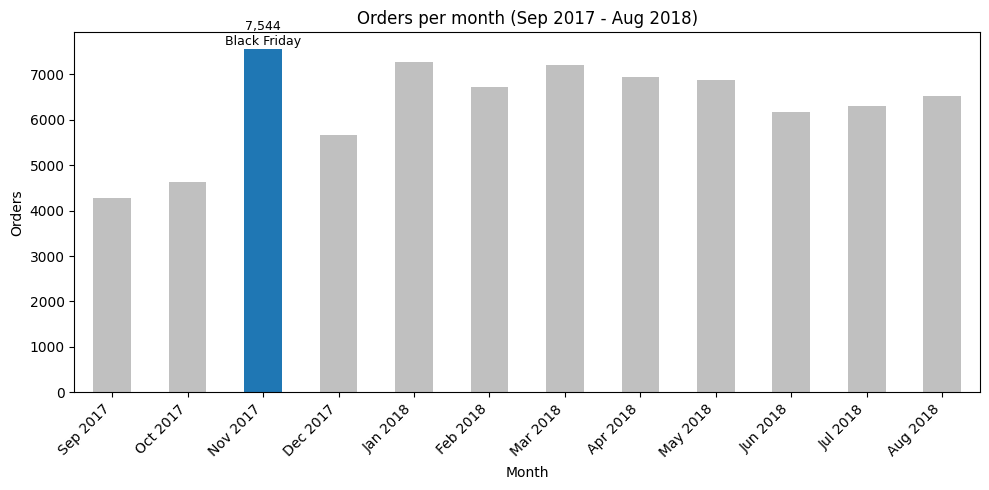

In [115]:
#Which month has the highest sales? Why? Is there seasonality?
#Use a 12-month window with complete data so each calendar month appears exactly once
df_orders_12m=df_orders[(df_orders['year_month']>=pd.Period('2017-09', freq='M')) &
                        (df_orders['year_month']<=pd.Period('2018-08', freq='M'))].copy()
df_orders_12m['month']=df_orders_12m['order_purchase_timestamp'].dt.month
#Group by calendar month and calculate the size
orders_per_month = df_orders_12m.groupby('month').size()
print(orders_per_month)
'''Brazilian festivities: 
    Second may sunday, Mothers day
    July, school vacations
    Second agust sunday, Fathers day
'''
#Plot: orders per month in chronological order, highlighting November (Black Friday)
orders_12m_by_period=df_orders_12m.groupby('year_month').size()

#Gray for all months, blue for November
colors=['tab:blue' if period.month==11 else 'silver' for period in orders_12m_by_period.index]

ax=orders_12m_by_period.plot(kind='bar', color=colors, figsize=(10, 5))
plt.title('Orders per month (Sep 2017 - Aug 2018)')
plt.xlabel('Month')
plt.ylabel('Orders')
ax.set_xticklabels([period.strftime('%b %Y') for period in orders_12m_by_period.index], rotation=45, ha='right')

#Label only the November bar
nov_position=[period.month for period in orders_12m_by_period.index].index(11)
nov_value=orders_12m_by_period.iloc[nov_position]
ax.text(nov_position, nov_value + 100, f'{nov_value:,}\nBlack Friday', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


   year_month      mean  count  month_index
0     2016-10  4.055866    179            0
1     2016-11  3.188119    101            1
3     2017-01  4.338912    239            3
4     2017-02  4.280962   1413            4
5     2017-03  4.033051   2481            5
6     2017-04  4.036983   2055            6
7     2017-05  4.100539   3710            7
8     2017-06  4.127616   3440            8
9     2017-07  4.183271   3503            9
10    2017-08  4.224961   4503           10
11    2017-09  4.182424   4199           11
12    2017-10  4.182188   4424           12
13    2017-11  4.114919   4786           13
14    2017-12  3.931596   7982           14
15    2018-01  4.063603   6179           15
16    2018-02  4.014260   6101           16
17    2018-03  3.727413   7803           17
18    2018-04  3.919857   7287           18
19    2018-05  4.193081   7458           19
20    2018-06  4.197171   6715           20
21    2018-07  4.288250   5634           21
22    2018-08  4.209747   8987  

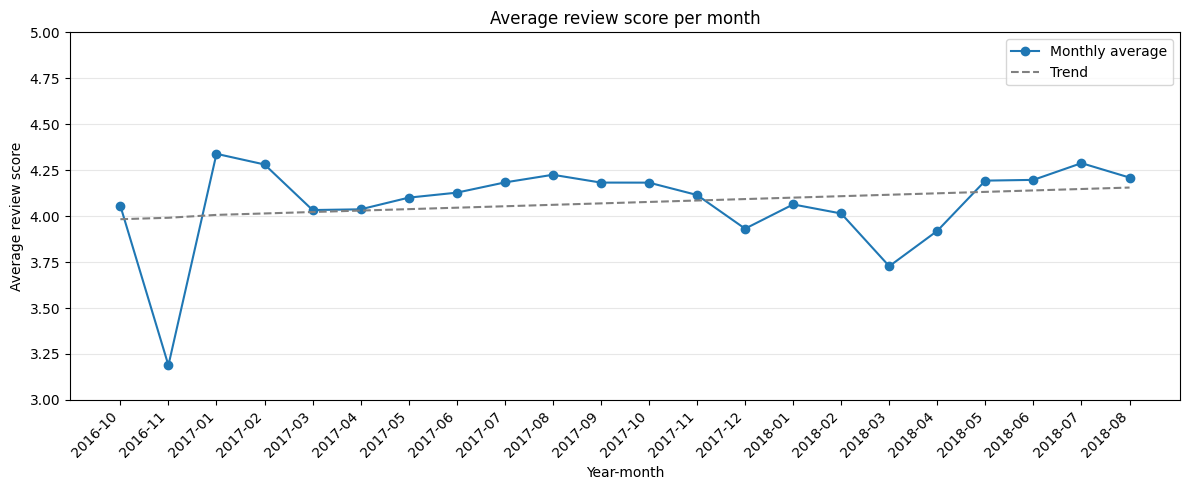

In [116]:
#Are ratings improving or worsening over time?
#Use year-month (to_period) so January 2017 and January 2018 stay separate
df_order_reviews['review_creation_date']=pd.to_datetime(df_order_reviews['review_creation_date'])
df_order_reviews['year_month']=df_order_reviews['review_creation_date'].dt.to_period('M')
df_review_rate_monthly=df_order_reviews.groupby('year_month')['review_score'].agg(['mean','count']).reset_index()

#Month number (0, 1, 2...) to measure the trend
df_review_rate_monthly['month_index']=range(len(df_review_rate_monthly))

#Keep only months with enough reviews to be reliable
df_review_rate_monthly=df_review_rate_monthly[df_review_rate_monthly['count']>=100]
print(df_review_rate_monthly)

#Trend: linear regression of the monthly average rating over time
slope, intercept, r_value, p_value, std_err = linregress(df_review_rate_monthly['month_index'], df_review_rate_monthly['mean'])
print(f"Slope: {slope:.4f} points per month ({slope*12:.2f} per year)")
print(f"P-value: {p_value:.4f}")

#Plot: monthly average rating and trend line
x_labels=df_review_rate_monthly['year_month'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(x_labels, df_review_rate_monthly['mean'], marker='o', label='Monthly average')
plt.plot(x_labels, intercept + slope * df_review_rate_monthly['month_index'],
         linestyle='--', color='gray', label='Trend')
plt.title('Average review score per month')
plt.xlabel('Year-month')
plt.ylabel('Average review score')
plt.ylim(3, 5)  # Zoomed enough to see changes without exaggerating them
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [117]:

'''5. GEOGRAPHY 🗺️
Which are the 5 states with the highest sales?
Is there a difference in price/satisfaction by region?
What is the freight cost by region?'''

'5. GEOGRAPHY 🗺️\nWhich are the 5 states with the highest sales?\nIs there a difference in price/satisfaction by region?\nWhat is the freight cost by region?'

In [118]:
df_geography=df_orders.merge(df_customer,on='customer_id',how='left')\
                        .merge(df_order_reviews,on='order_id',how='left')
#Which are the 5 states with the highest sales?
df_sales_by_states=df_geography.groupby('customer_state')['review_score'].size().reset_index().sort_values(by='review_score',ascending=False)
print(df_sales_by_states.head(5))

   customer_state  review_score
25             SP         41964
18             RJ         12930
10             MG         11706
22             RS          5506
17             PR          5064


In [119]:
#Is there a difference in price/satisfaction by region?
df_reviews_and_categories_location=df_order_reviews.merge(df_order_items,on='order_id',how='left')\
                            .merge(df_products,on='product_id',how='left')\
                            .merge(df_location,)
correlation_price_review=df_reviews_and_categories['price'].corr(df_reviews_and_categories['review_score'])
print(correlation_price_review)

MergeError: No common columns to perform merge on. Merge options: left_on=None, right_on=None, left_index=False, right_index=False

In [ ]:
#What is the freight cost by region?


In [ ]:

'''6. COMPARISONS 🔄
Expensive vs. cheap products: which sells more?
Do more expensive products have better or worse ratings?
Does Category A sell more than Category B?'''